# Модель выявления аномалий (Isolation Forest)

**Вход:** `clean_final.csv` - очищенный датасет из `pipeline_final.ipynb` (25 002 записи с флагами аномалий по правилам).

**Идея:** правила ловят то, что мы придумали заранее. Модель может найти паттерны, о которых мы не подумали.

**Подход - semi-supervised:**
1. Берём только «чистые» записи (без аномалий по правилам) - модель учит, как выглядит **нормальная** запись
2. Предсказываем на **всём** датасете
3. Проверяем: ловит ли модель те же аномалии, что правила? Что нового нашла?

Это лучше, чем обучать на всём: модель не путает аномалии с нормой.

## Загрузка данных

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")

# Загружаем результат pipeline_final
df = pd.read_csv("data/hakaton_cleaned.csv", parse_dates=["bdate", "test_date", "guard_bdate"])

print(f"Загружено: {len(df)} записей")
print(f"Уникальных детей: {df["person_id"].nunique()}")
print(f"Аномалий по правилам: {df["has_anomaly"].sum()} ({df["has_anomaly"].mean()*100:.1f}%)")
print(f"Чистых записей: {(~df["has_anomaly"]).sum()}")

Загружено: 25002 записей
Уникальных детей: 20522
Аномалий по правилам: 1837 (7.3%)
Чистых записей: 23165


## Feature Engineering

Из каждой записи извлекаем числовые признаки. Модель не понимает ФИО и даты - ей нужны числа.

**Признаки записи** (что можно вычислить из одной строки):
- `child_age` - возраст ребёнка на момент теста
- `parent_age_at_birth` - возраст родителя при рождении ребёнка
- `age_class_diff` - отклонение реального возраста от ожидаемого (класс + 6 лет)
- `id_eq_guard` - совпадает ли id ребёнка с id родителя (1/0)
- `same_school` - направляющая школа = площадка тестирования (1/0)
- `class_num` - номер класса

**Агрегаты по ребёнку** (нужно знать все записи этого person_id):
- `n_tests` - сколько раз тестировался всего
- `n_classes` - за сколько разных классов
- `min_gap` - минимальный интервал между тестами
- `max_class_jump` - максимальный скачок класса

In [2]:
# Признаки из одной записи
df["class_num"] = pd.to_numeric(df["class"], errors="coerce")
df["child_age"] = (df["test_date"] - df["bdate"]).dt.days / 365.25
df["parent_age_at_birth"] = (df["bdate"] - df["guard_bdate"]).dt.days / 365.25
df["age_class_diff"] = df["child_age"] - (df["class_num"] + 6)
df["id_eq_guard"] = (df["id_doc"] == df["guard_id_doc"]).astype(int)
df["same_school"] = (df["ogrn_naprav"] == df["ogrn_area"]).astype(int)

# Агрегаты по person_id

# Количество тестов и классов
person_stats = df.groupby("person_id").agg(
    n_tests=("test_date", "count"),
    n_classes=("class_num", "nunique"),
).reset_index()

# Минимальный интервал между тестами
df_sorted = df.sort_values(["person_id", "test_date"])
df_sorted["days_gap"] = (
    df_sorted["test_date"] - df_sorted.groupby("person_id")["test_date"].shift(1)
).dt.days
gap_stats = df_sorted.groupby("person_id")["days_gap"].agg(min_gap="min").reset_index()
gap_stats["min_gap"] = gap_stats["min_gap"].fillna(999)

# Максимальный скачок класса
def max_class_jump(group):
    classes = group.sort_values("test_date")["class_num"].dropna().values
    if len(classes) < 2:
        return 0
    return max(abs(classes[i] - classes[i-1]) for i in range(1, len(classes)))

jump_stats = df.groupby("person_id").apply(max_class_jump).reset_index()
jump_stats.columns = ["person_id", "max_class_jump"]

# Мёржим всё обратно
df = df.merge(person_stats, on="person_id", how="left")
df = df.merge(gap_stats, on="person_id", how="left")
df = df.merge(jump_stats, on="person_id", how="left")

# Итоговый набор фичей
feature_cols = [
    "child_age", "parent_age_at_birth", "age_class_diff",
    "id_eq_guard", "same_school",
    "n_tests", "n_classes", "min_gap", "max_class_jump", "class_num"
]

X = df[feature_cols].fillna(0)
print(f"Матрица признаков: {X.shape}")
print(X.describe().round(2))

Матрица признаков: (25002, 10)
       child_age  parent_age_at_birth  age_class_diff  id_eq_guard  \
count   25002.00             25002.00        25002.00     25002.00   
mean        9.70                28.10            0.44         0.01   
std         2.86                 5.75            0.91         0.11   
min         4.65                 5.00           -8.87         0.00   
25%         7.30                23.99           -0.04         0.00   
50%         8.54                27.37            0.29         0.00   
75%        11.84                31.33            0.71         0.00   
max        19.01                86.00           10.99         1.00   

       same_school   n_tests  n_classes   min_gap  max_class_jump  class_num  
count     25002.00  25002.00   25002.00  25002.00        25002.00   25002.00  
mean          0.11      1.42       1.06    693.86            0.11       3.27  
std           0.32      0.70       0.29    428.71            0.66       2.76  
min           0.00    

## Разделение на train / test

**Semi-supervised подход:**
- **Train** - только чистые записи (`has_anomaly == False`). Модель учит «как выглядит нормальная запись».
- **Test** - весь датасет целиком. Модель оценивает каждую запись: похожа на нормальную или нет.

Дополнительно внутри train делаем 80/20 split для проверки стабильности.

In [3]:
# Чистые записи - обучающая выборка
clean_mask = ~df["has_anomaly"]
X_clean = X[clean_mask]

# 80/20 split внутри чистых для валидации
X_train, X_val = train_test_split(X_clean, test_size=0.2, random_state=42)

print(f"Чистых записей (обучение): {len(X_clean)}")
print(f"  Train: {len(X_train)}")
print(f"  Validation: {len(X_val)}")
print(f"Весь датасет (предсказание): {len(X)}")
print(f"  Из них аномалий по правилам: {df["has_anomaly"].sum()}")

Чистых записей (обучение): 23165
  Train: 18532
  Validation: 4633
Весь датасет (предсказание): 25002
  Из них аномалий по правилам: 1837


## Обучение Isolation Forest

**Как работает Isolation Forest:**
- Строит 200 случайных деревьев
- Каждое дерево случайно выбирает признак и точку разреза, делит данные пополам
- «Нормальная» запись окружена тысячами похожих ---> нужно много разрезов чтобы её изолировать
- «Аномальная» запись непохожа на остальные ---> изолируется за 2-3 разреза
- `anomaly_score` = среднее число разрезов. Чем меньше ---> тем аномальнее

Обучаем **только на чистых данных** (train), предсказываем на **всём датасете**.

In [4]:
# Масштабирование: приводим все фичи к одному диапазону
scaler = StandardScaler()
scaler.fit(X_train)  # fit только на train!

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_all_scaled = scaler.transform(X)

# Обучение модели
model = IsolationForest(
    n_estimators=200,     # 200 деревьев
    contamination=0.05,   # ожидаем ~5% аномалий среди чистых (запас на ошибки правил)
    random_state=42
)
model.fit(X_train_scaled)  # обучаем ТОЛЬКО на чистых!

print("Модель обучена на чистых записях")

Модель обучена на чистых записях


## Валидация на hold-out

Проверяем на 20% чистых записей, которые модель не видела при обучении.
Если модель хорошая - почти все validation записи она должна считать нормальными.

In [5]:
# Предсказание на validation (тоже чистые записи - модель не видела)
val_scores = model.decision_function(X_val_scaled)
val_preds = model.predict(X_val_scaled)
val_anomaly_rate = (val_preds == -1).mean()

print(f"Validation ({len(X_val)} чистых записей, модель их не видела):")
print(f"  Помечено как аномалия: {(val_preds == -1).sum()} ({val_anomaly_rate*100:.1f}%)")
print(f"  Помечено как норма: {(val_preds == 1).sum()} ({(val_preds == 1).mean()*100:.1f}%)")
print(f"")
if val_anomaly_rate < 0.10:
    print(f"Модель стабильна: false positive rate {val_anomaly_rate*100:.1f}% на чистых данных")
else:
    print(f"Высокий false positive rate: {val_anomaly_rate*100:.1f}%")

Validation (4633 чистых записей, модель их не видела):
  Помечено как аномалия: 241 (5.2%)
  Помечено как норма: 4392 (94.8%)

Модель стабильна: false positive rate 5.2% на чистых данных


## Предсказание на всём датасете

In [6]:
# Предсказание на ВСЕХ записях (и чистых, и аномальных по правилам)
df["anomaly_score"] = model.decision_function(X_all_scaled)
df["model_anomaly"] = model.predict(X_all_scaled) == -1

print(f"Результаты модели на всём датасете ({len(df)} записей):")
print(f"  Аномалий по модели: {df["model_anomaly"].sum()} ({df["model_anomaly"].mean()*100:.1f}%)")
print(f"  Нормальных по модели: {(~df["model_anomaly"]).sum()}")

Результаты модели на всём датасете (25002 записей):
  Аномалий по модели: 2070 (8.3%)
  Нормальных по модели: 22932


## Сравнение: модель vs правила

Матрица пересечения - что нашли правила, что модель, что оба.

In [7]:
both = (df["model_anomaly"] & df["has_anomaly"]).sum()
model_only = (df["model_anomaly"] & ~df["has_anomaly"]).sum()
rule_only = (~df["model_anomaly"] & df["has_anomaly"]).sum()
neither = (~df["model_anomaly"] & ~df["has_anomaly"]).sum()

print(f"{"":20} | Модель: ДА  | Модель: НЕТ")
print(f"{"-"*55}")
print(f"{"Правила: ДА":20} | {both:>10}  | {rule_only:>11}")
print(f"{"Правила: НЕТ":20} | {model_only:>10}  | {neither:>11}")
print()
print(f"Совпадение (оба):    {both}  - модель подтверждает правила")
print(f"Только модель:       {model_only}  - НОВЫЕ НАХОДКИ")
print(f"Только правила:      {rule_only}  - модель не считает аномалией")
print(f"Чистые (оба):        {neither}")

# Recall модели: какую долю аномалий по правилам модель поймала?
recall = both / (both + rule_only) * 100
print(f"\nRecall модели (доля пойманных аномалий правил): {recall:.1f}%")

                     | Модель: ДА  | Модель: НЕТ
-------------------------------------------------------
Правила: ДА          |        902  |         935
Правила: НЕТ         |       1168  |       21997

Совпадение (оба):    902  - модель подтверждает правила
Только модель:       1168  - НОВЫЕ НАХОДКИ
Только правила:      935  - модель не считает аномалией
Чистые (оба):        21997

Recall модели (доля пойманных аномалий правил): 49.1%


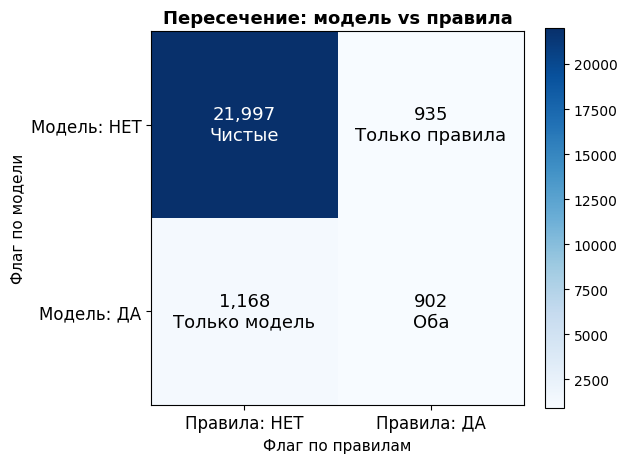

In [8]:
# Тепловая карта: модель vs правила
import numpy as np

conf = np.array([[neither, rule_only],
                 [model_only, both]])
labels = np.array([[f"{neither:,}\nЧистые", f"{rule_only:,}\nТолько правила"],
                   [f"{model_only:,}\nТолько модель", f"{both:,}\nОба"]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Правила: НЕТ", "Правила: ДА"], fontsize=12)
ax.set_yticklabels(["Модель: НЕТ", "Модель: ДА"], fontsize=12)
ax.set_xlabel("Флаг по правилам", fontsize=11)
ax.set_ylabel("Флаг по модели", fontsize=11)
ax.set_title("Пересечение: модель vs правила", fontsize=13, fontweight="bold")

for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i, j], ha="center", va="center",
                fontsize=13, color="white" if conf[i, j] > conf.max() / 2 else "black")

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Анализ новых находок модели

Смотрим: чем записи «только модель» отличаются от среднего?

In [9]:
new_finds = df[df["model_anomaly"] & ~df["has_anomaly"]].copy()

print(f"Новых находок модели: {len(new_finds)}")
print(f"\n{"Признак":25} | {"Новые":>10} | {"Всё":>10} | {"Разница":>10}")
print(f"{"-"*60}")

for col in feature_cols:
    m_new = new_finds[col].mean()
    m_all = df[col].mean()
    diff = m_new - m_all
    marker = " <<<" if abs(diff) > 1 else ""
    print(f"{col:25} | {m_new:10.2f} | {m_all:10.2f} | {diff:+10.2f}{marker}")

Новых находок модели: 1168

Признак                   |      Новые |        Всё |    Разница
------------------------------------------------------------
child_age                 |      11.77 |       9.70 |      +2.06 <<<
parent_age_at_birth       |      28.99 |      28.10 |      +0.89
age_class_diff            |       0.68 |       0.44 |      +0.25
id_eq_guard               |       0.00 |       0.01 |      -0.01
same_school               |       0.43 |       0.11 |      +0.31
n_tests                   |       2.08 |       1.42 |      +0.66
n_classes                 |       1.52 |       1.06 |      +0.46
min_gap                   |     281.16 |     693.86 |    -412.70 <<<
max_class_jump            |       0.54 |       0.11 |      +0.43
class_num                 |       5.08 |       3.27 |      +1.81 <<<


In [10]:
# Главная находка: same_school
pct_new = new_finds["same_school"].mean() * 100
pct_all = df["same_school"].mean() * 100

print(f"\n{"="*60}")
print(f"КЛЮЧЕВАЯ НАХОДКА: same_school (ogrn_naprav == ogrn_area)")
print(f"{"="*60}")
print(f"")
print(f"  В новых находках модели: {pct_new:.1f}%")
print(f"  Во всём датасете:        {pct_all:.1f}%")
print(f"  Превышение:              в {pct_new/max(pct_all,0.01):.1f} раз")
print(f"")
print(f"  Школа направляет ребёнка на тестирование")
print(f"  и сама же проводит это тестирование.")
print(f"  Потенциальный конфликт интересов.")


КЛЮЧЕВАЯ НАХОДКА: same_school (ogrn_naprav == ogrn_area)

  В новых находках модели: 42.6%
  Во всём датасете:        11.4%
  Превышение:              в 3.7 раз

  Школа направляет ребёнка на тестирование
  и сама же проводит это тестирование.
  Потенциальный конфликт интересов.


## Важность признаков

Какие признаки сильнее всего влияют на решение модели?
Отрицательная корреляция = чем больше признак, тем аномальнее запись.

In [11]:
correlations = df[feature_cols + ["anomaly_score"]].corr()["anomaly_score"].drop("anomaly_score")

print(f"{"Признак":25} | {"Корреляция":>11} | Интерпретация")
print(f"{"-"*75}")

for feat in correlations.abs().sort_values(ascending=False).index:
    r = correlations[feat]
    if r < -0.1:
        interp = "↑ больше = аномальнее"
    elif r > 0.1:
        interp = "↑ больше = нормальнее"
    else:
        interp = "слабое влияние"
    print(f"{feat:25} | r = {r:+.3f}   | {interp}")

Признак                   |  Корреляция | Интерпретация
---------------------------------------------------------------------------
n_classes                 | r = -0.578   | ↑ больше = аномальнее
n_tests                   | r = -0.561   | ↑ больше = аномальнее
min_gap                   | r = +0.485   | ↑ больше = нормальнее
max_class_jump            | r = -0.480   | ↑ больше = аномальнее
child_age                 | r = -0.480   | ↑ больше = аномальнее
same_school               | r = -0.434   | ↑ больше = аномальнее
class_num                 | r = -0.411   | ↑ больше = аномальнее
age_class_diff            | r = -0.262   | ↑ больше = аномальнее
id_eq_guard               | r = -0.144   | ↑ больше = аномальнее
parent_age_at_birth       | r = -0.063   | слабое влияние


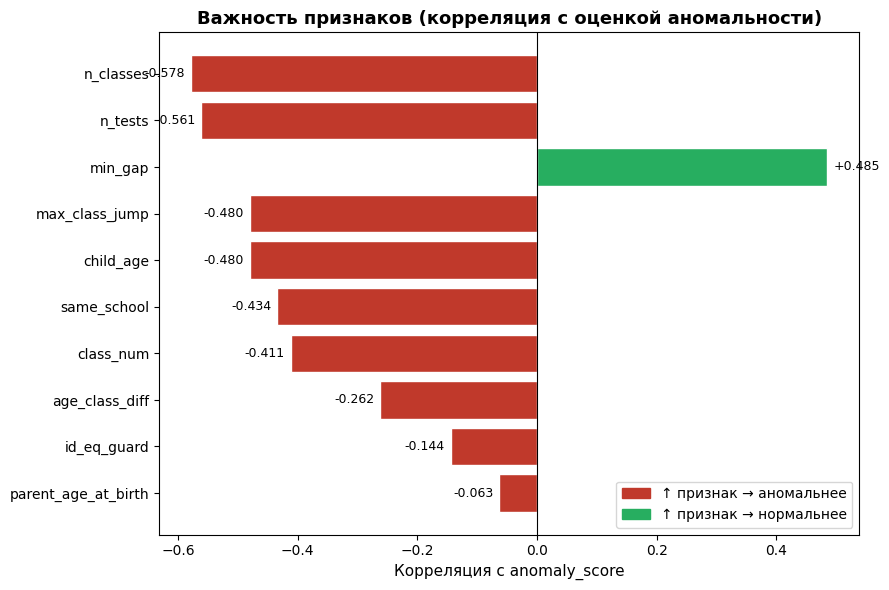

In [12]:
# Feature importance: горизонтальный бар-чарт корреляций с anomaly_score
corr_sorted = correlations.reindex(correlations.abs().sort_values().index)
bar_colors = ["#c0392b" if v < 0 else "#27ae60" for v in corr_sorted]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=bar_colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Корреляция с anomaly_score", fontsize=11)
ax.set_title("Важность признаков (корреляция с оценкой аномальности)", fontsize=13, fontweight="bold")

for bar, val in zip(bars, corr_sorted.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#c0392b", label="↑ признак → аномальнее"),
                   Patch(color="#27ae60", label="↑ признак → нормальнее")],
          loc="lower right")
plt.tight_layout()
plt.show()

## Топ самых аномальных записей

In [13]:
top = df.nsmallest(15, "anomaly_score")

print("Топ-15 самых аномальных записей по модели:\n")
for _, r in top.iterrows():
    rule_flag = "ПРАВИЛА+МОДЕЛЬ" if r["has_anomaly"] else "ТОЛЬКО МОДЕЛЬ"
    print(f"  [{rule_flag}] {r["last_name"]} {r["first_name"]} | "
          f"class={r["class"]} | age={r["child_age"]:.1f} | "
          f"tests={r["n_tests"]} | classes={r["n_classes"]} | "
          f"min_gap={r["min_gap"]:.0f}d | "
          f"same_school={r["same_school"]} | "
          f"score={r["anomaly_score"]:.3f}")

Топ-15 самых аномальных записей по модели:

  [ПРАВИЛА+МОДЕЛЬ] КУЛАГИНА АНТОНИНА | class=10 | age=17.6 | tests=5 | classes=4 | min_gap=0d | same_school=1 | score=-0.191
  [ПРАВИЛА+МОДЕЛЬ] ЯКОВЛЕВ МИХАИЛ | class=8 | age=16.8 | tests=4 | classes=2 | min_gap=0d | same_school=1 | score=-0.183
  [ПРАВИЛА+МОДЕЛЬ] ДОБРЯКОВ ПЕТР | class=8 | age=16.6 | tests=4 | classes=2 | min_gap=0d | same_school=1 | score=-0.181
  [ПРАВИЛА+МОДЕЛЬ] ТИХОНЕНКО МАРИО | class=5 | age=13.4 | tests=4 | classes=3 | min_gap=0d | same_school=1 | score=-0.177
  [ПРАВИЛА+МОДЕЛЬ] КУЛАГИНА АНТОНИНА | class=8 | age=17.8 | tests=5 | classes=4 | min_gap=0d | same_school=0 | score=-0.177
  [ПРАВИЛА+МОДЕЛЬ] ПЕТРОВСКАЯ ТАТЬЯНА | class=9 | age=17.9 | tests=6 | classes=6 | min_gap=0d | same_school=0 | score=-0.177
  [ПРАВИЛА+МОДЕЛЬ] ЗАРУБА ГАЛИНА | class=6 | age=17.6 | tests=4 | classes=2 | min_gap=59d | same_school=1 | score=-0.176
  [ПРАВИЛА+МОДЕЛЬ] ЗАРУБА ГАЛИНА | class=6 | age=17.3 | tests=4 | classes=2 | min_gap=59d | same_s

## Итого и сохранение

**Два слоя проверки:**
- **Правила** - ловят конкретные технические ошибки (частота, скачки классов, совпадение ID)
- **Модель** - находит записи «непохожие на нормальные» по совокупности признаков

**Ключевая находка модели:** паттерн `same_school` - школа сама направляет и сама тестирует. Правила это не проверяли.

In [14]:
# Объединённый флаг
df["combined_anomaly"] = df["has_anomaly"] | df["model_anomaly"]

print(f"Итоговая статистика:")
print(f"  Аномалий по правилам:  {df["has_anomaly"].sum()}")
print(f"  Аномалий по модели:    {df["model_anomaly"].sum()}")
print(f"  Объединённый флаг:     {df["combined_anomaly"].sum()} ({df["combined_anomaly"].mean()*100:.1f}%)")
print(f"  Чистых записей:        {(~df["combined_anomaly"]).sum()}")

# Сохраняем
export_cols = [c for c in df.columns if c not in [
    "person_key", "class_num", "child_age", "parent_age_at_birth"
]]
df[export_cols].to_csv("data/dataset_with_model_scores.csv", index=False)
print(f"\nСохранено: data/dataset_with_model_scores.csv")

Итоговая статистика:
  Аномалий по правилам:  1837
  Аномалий по модели:    2070
  Объединённый флаг:     3005 (12.0%)
  Чистых записей:        21997

Сохранено: data/dataset_with_model_scores.csv
